# House Prices - Advanced Regression Techniques

## Features

Versión anterior - Boston Housing Dataset

Metadatos:


Metas:
Predecir los precios de las ventas para cada casa (para cada ID en el *test set*)
Tienes que predecir el valor de la variable *SalesPrice*

Métricas:
Se evaluan a partir del RMSE (Root Mean Squared Error) entre el logaritmo del valor predicto y el logaritmo de los precios de ventas observados.

In [1]:
import pandas as pd

In [2]:
# Importación de datos

df_entrenamiento = pd.read_csv("train.csv")
df_pruebas = pd.read_csv("test.csv")
df_muestra = pd.read_csv("sample_submission.csv")

Utilizamos el dataset de entrenamiento ya que con esta información será la calidad del modelo

In [3]:
df_entrenamiento.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Forma y tipo de datos.
df_entrenamiento.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

La pregunta objetivo es:

- ¿Cuanto valdrán las casas en un futuro? | Determinar los precios de venta futuros

Siempre es bueno utilizar gráficas para dar una descripción de los datos. ¿Pero, que gráficas nos serán óptimas y que variables son importantes para su representación gráfica?

Primeramente utilizaremos una gráfica de distribución (histograma) para la variable principal *SalePrice*

In [5]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     -------------------------------------- - 51.2/52.8 kB 1.3 MB/s eta 0:00:01
     -------------------------------------- - 51.2/52.8 kB 1.3 MB/s eta 0:00:01
     -------------------------------------- - 51.2/52.8 kB 1.3 MB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 304.2 kB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/116.4 kB ? eta -:--:--
     ------------------------------------ - 112.6/116.4 kB 2.2 MB/s eta 0:00:01
     -------------------------------------- 116.4/116.4 kB 2.3 MB/s eta 0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
    --------------------------------------- 0.2/8.1 MB 5.9 MB/s eta 0:00:02
   --- ------------------------------------ 0.6


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Figure size 900x800 with 0 Axes>

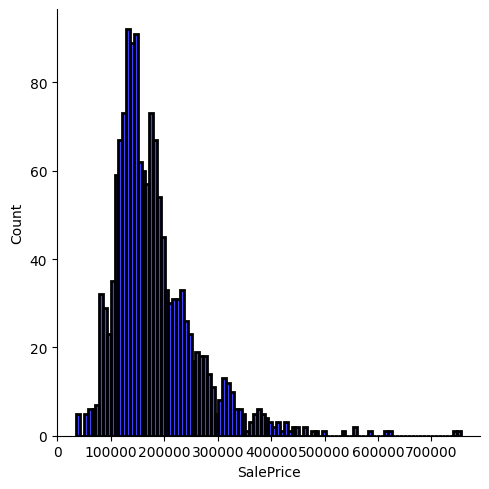

In [14]:
import seaborn as sns
from matplotlib import pyplot as plt

plt.figure(figsize=(9,8))
sns.displot(df_entrenamiento['SalePrice'], color = 'b', bins = 100, edgecolor="k", linewidth=2)



Ya que los modelos de predicción toman tipos de valores particulares, vamos a separar los cuantitativos de los cualitativos

In [30]:
set(df_entrenamiento.dtypes.tolist())



{dtype('int64'), dtype('float64'), dtype('O')}

[dtype('int64'),
 dtype('int64'),
 dtype('O'),
 dtype('float64'),
 dtype('int64'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('float64'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('int64'),
 dtype('O'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('O'),
 dtype('int64'),
 dtype('O'),
 dtype('int64'),
 dtype('O'),
 dtype('O'),
 dtype('float64'),
 dtype('O'),
 dtype('int64'),
 dtype('int64'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('int64'),
 dtype(